# Employee Attrition Analysis

Real EDA and a real, working attrition-prediction pipeline over IBM's
HR Employee Attrition dataset (1,470 employees, 35 columns).

This is a rebuild of an uploaded notebook whose EDA and attrition-rate
sections were genuine and ran correctly, but whose entire modeling
section — everything after "ENCODING FOR MACHINE LEARNING" — never
actually ran: it referenced a `target` variable and a `df_encoded`
dataframe that were never defined, so every cell from there onward
failed with `NameError` (and, once, `NotFittedError` on a model that
was referenced but never `.fit()`). No model, confusion matrix, or
saved artifact was ever produced by the original. That pipeline is
reconstructed from scratch here, alongside two other real fixes (see
markdown notes inline) found while doing so.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Cleaning

`EmployeeCount`, `StandardHours`, and `Over18` are constant across
every row (1, 80, and "Y" respectively) — they carry zero information
and were never dropped in the original. `EmployeeNumber` is a row ID.
None of the four belong in a model.

In [2]:
print("EmployeeCount unique:", df["EmployeeCount"].unique())
print("StandardHours unique:", df["StandardHours"].unique())
print("Over18 unique:", df["Over18"].unique())
print("Nulls:", df.isnull().sum().sum())

df = df.drop(columns=["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"])
df["Attrition_Flag"] = df["Attrition"].map({"Yes": 1, "No": 0})
df.shape

EmployeeCount unique: [1]
StandardHours unique: [80]
Over18 unique: <ArrowStringArray>
['Y']
Length: 1, dtype: str
Nulls: 0


(1470, 32)

## Ordinal fields: one consistent mapping, used for display only

The original notebook and the original `attrition.py` app each
invented their **own** text labels for the same 1-5 integer codes —
and they disagree with each other (e.g. `PerformanceRating` 2 is
"Average" in the app but "Good" in the notebook). If either mapping
had been used to build model features via string dummy columns, the
app and the trained model would have silently misaligned.

The fix here: model on the **raw integer codes** everywhere (single
source of truth), and keep exactly **one** label dictionary, used only
to make charts readable — never fed into the model.

In [3]:
ORDINAL_LABELS = {
    "Education": {1: "Below College", 2: "College", 3: "Bachelor", 4: "Master", 5: "Doctor"},
    "EnvironmentSatisfaction": {1: "Low", 2: "Medium", 3: "High", 4: "Very High"},
    "JobInvolvement": {1: "Low", 2: "Medium", 3: "High", 4: "Very High"},
    "JobSatisfaction": {1: "Low", 2: "Medium", 3: "High", 4: "Very High"},
    "RelationshipSatisfaction": {1: "Low", 2: "Medium", 3: "High", 4: "Very High"},
    "PerformanceRating": {1: "Low", 2: "Good", 3: "Excellent", 4: "Outstanding"},
    "WorkLifeBalance": {1: "Bad", 2: "Good", 3: "Better", 4: "Best"},
}

def labeled(frame, col):
    return frame[col].map(ORDINAL_LABELS[col])

labeled(df, "JobSatisfaction").value_counts()

JobSatisfaction
Very High    459
High         442
Low          289
Medium       280
Name: count, dtype: int64

## Overall attrition rate

Total Employees: 1470
Employees Who Left: 237
Attrition Rate: 16.12%


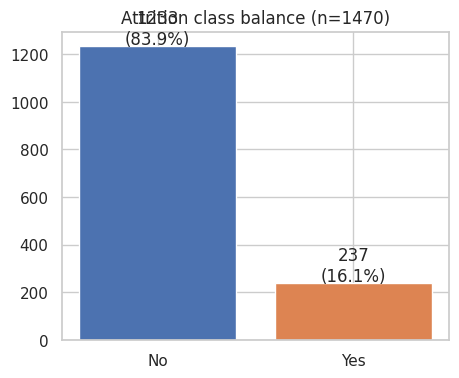

In [4]:
total = len(df)
left = int(df["Attrition_Flag"].sum())
rate = left / total
print(f"Total Employees: {total}")
print(f"Employees Who Left: {left}")
print(f"Attrition Rate: {rate:.2%}")

fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Attrition"].value_counts()
ax.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, f"{v}\n({v/total:.1%})", ha="center")
ax.set_title(f"Attrition class balance (n={total})")
plt.show()

## EDA: who leaves?

Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition_Flag, dtype: float64


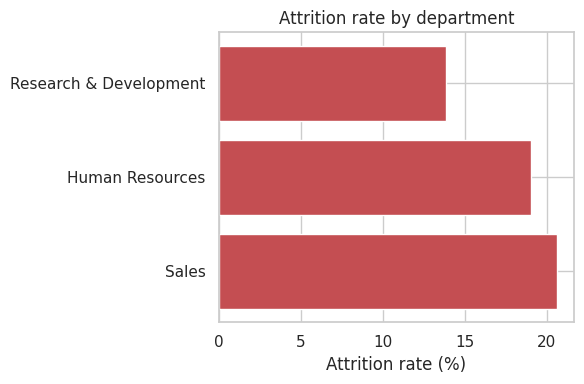

In [5]:
dept_attr = df.groupby("Department")["Attrition_Flag"].mean().sort_values(ascending=False)
print((dept_attr * 100).round(2))

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(dept_attr.index, dept_attr.values * 100, color="#C44E52")
ax.set_xlabel("Attrition rate (%)")
ax.set_title("Attrition rate by department")
plt.tight_layout()
plt.show()

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition_Flag, dtype: float64


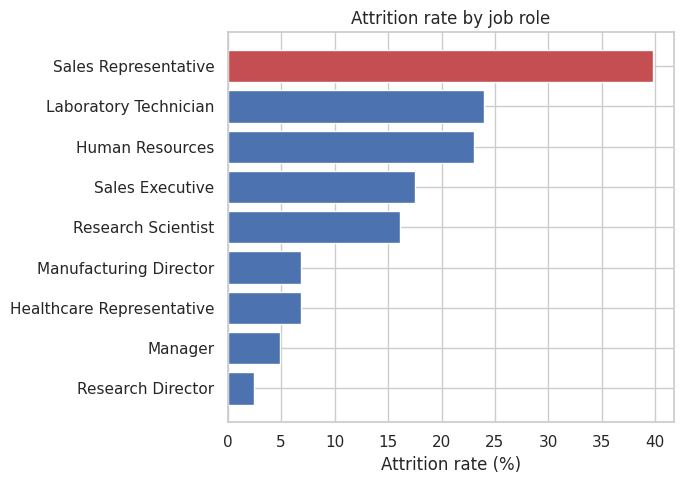

In [6]:
role_attr = df.groupby("JobRole")["Attrition_Flag"].mean().sort_values(ascending=False)
print((role_attr * 100).round(2))

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#C44E52" if v == role_attr.max() else "#4C72B0" for v in role_attr.values]
ax.barh(role_attr.index[::-1], role_attr.values[::-1] * 100, color=colors[::-1])
ax.set_xlabel("Attrition rate (%)")
ax.set_title("Attrition rate by job role")
plt.tight_layout()
plt.show()

**Sales Representative is the clear highest at ~39.8%** — roughly
double the #2 role (Laboratory Technician, ~23.9%). The original app's
"Sales Representatives and Technicians have the highest attrition"
claim lumps these two together as if they're tied; they aren't — Sales
Representative is in a class of its own here.

IncomeQuartile
Low          29.27
Medium       14.21
High         10.63
Very High    10.33
Name: Attrition_Flag, dtype: float64


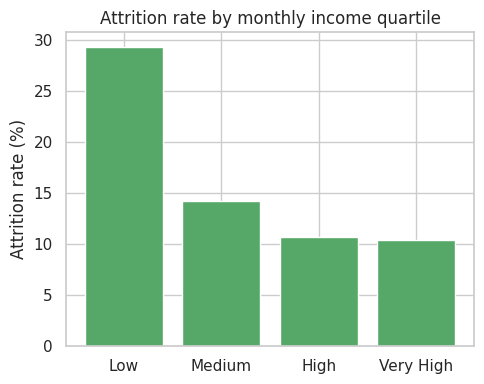

In [7]:
df["IncomeQuartile"] = pd.qcut(df["MonthlyIncome"], 4, labels=["Low", "Medium", "High", "Very High"])
income_attr = df.groupby("IncomeQuartile")["Attrition_Flag"].mean()
print((income_attr * 100).round(2))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(income_attr.index.astype(str), income_attr.values * 100, color="#55A868")
ax.set_ylabel("Attrition rate (%)")
ax.set_title("Attrition rate by monthly income quartile")
plt.tight_layout()
plt.show()

YearsAtCompany
(-1, 2]      29.82
(2, 5]       13.82
(5, 10]      12.28
(10, 20]      6.67
(20, 100]    12.12
Name: Attrition_Flag, dtype: float64


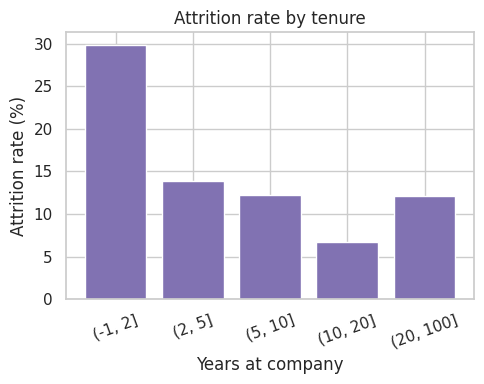

In [8]:
tenure_attr = df.groupby(pd.cut(df["YearsAtCompany"], bins=[-1, 2, 5, 10, 20, 100]))["Attrition_Flag"].mean()
print((tenure_attr * 100).round(2))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(tenure_attr.index.astype(str), tenure_attr.values * 100, color="#8172B2")
ax.set_ylabel("Attrition rate (%)")
ax.set_xlabel("Years at company")
ax.set_title("Attrition rate by tenure")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Attrition drops steadily through the first 10 years, then ticks
back up for 20+ year veterans (12.1%, above the 10-20 year band's
6.7%). Real and worth flagging rather than smoothing into a clean
monotonic story — it's a small group (fewer than 150 employees), so
read it as a real pattern in this sample rather than a strong causal
claim.

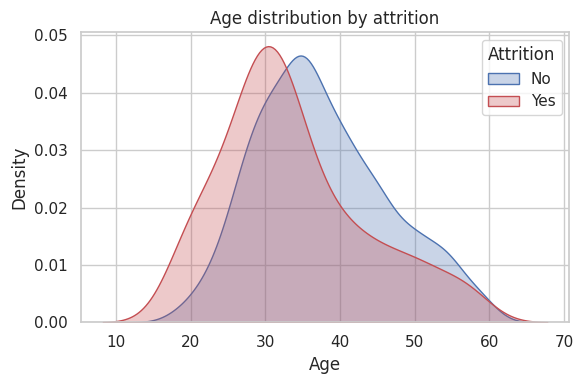

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
for label, color in [("No", "#4C72B0"), ("Yes", "#C44E52")]:
    sns.kdeplot(df.loc[df["Attrition"] == label, "Age"], label=label, color=color, fill=True, alpha=0.3, ax=ax)
ax.set_title("Age distribution by attrition")
ax.legend(title="Attrition")
plt.tight_layout()
plt.show()

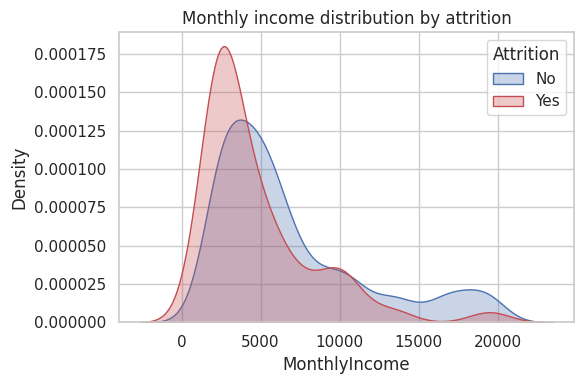

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
for label, color in [("No", "#4C72B0"), ("Yes", "#C44E52")]:
    sns.kdeplot(df.loc[df["Attrition"] == label, "MonthlyIncome"], label=label, color=color, fill=True, alpha=0.3, ax=ax)
ax.set_title("Monthly income distribution by attrition")
ax.legend(title="Attrition")
plt.tight_layout()
plt.show()

OverTime
No     10.44
Yes    30.53
Name: Attrition_Flag, dtype: float64


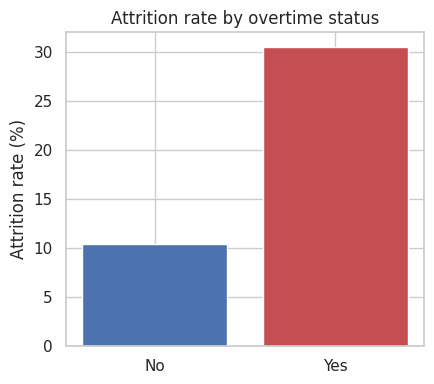

In [11]:
ot_attr = df.groupby("OverTime")["Attrition_Flag"].mean()
print((ot_attr * 100).round(2))

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.bar(ot_attr.index, ot_attr.values * 100, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Attrition rate (%)")
ax.set_title("Attrition rate by overtime status")
plt.tight_layout()
plt.show()

Employees working overtime leave at **~3x** the rate of those who
don't (30.5% vs 10.4%) — the single starkest split in the dataset.

## Correlation heatmap

The original notebook's `select_dtypes(include="number")` call is
safe here — a direct check confirms there are no boolean-dtype columns
in this dataset (unlike the diabetes dataset rebuilt earlier), so
nothing is silently excluded the way it was there. The one real fix
this chart needed: the original never passed `annot=True`, so no
correlation values were ever visible on the plot.

bool-dtype columns found: []


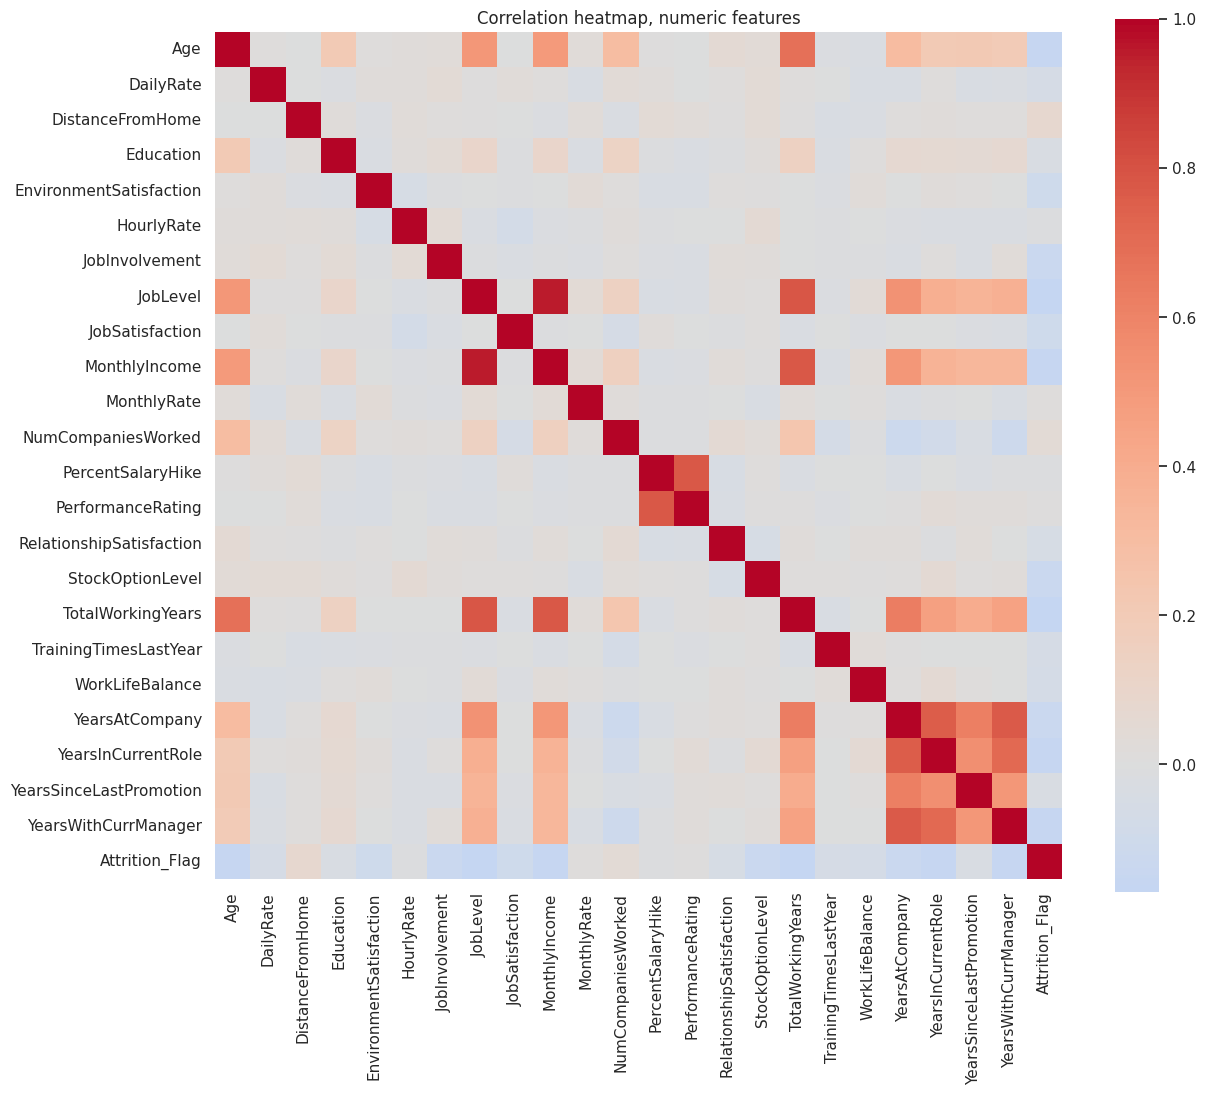

In [12]:
numeric_cols = df.select_dtypes(include="number").columns
print("bool-dtype columns found:", list(df.select_dtypes(include="bool").columns))

fig, ax = plt.subplots(figsize=(13, 11))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True, ax=ax)
ax.set_title("Correlation heatmap, numeric features")
plt.tight_layout()
plt.show()

## Job satisfaction fields vs. attrition

The original notebook silently overwrote `df["JobSatisfaction"]` back
to numeric in place for this one chart, breaking the symmetry with the
other three ordinal satisfaction columns (which stayed string-labeled
for the rest of the notebook). Here, the display labels are computed
into a **separate** variable each time — `df` itself is never
mutated — so nothing downstream is affected by having made this
chart.

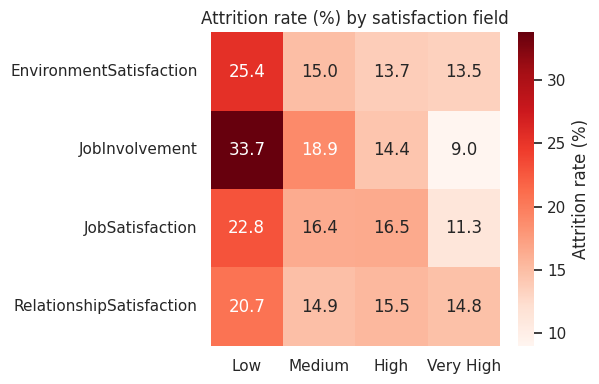

dtype('int64')

In [13]:
sat_cols = ["EnvironmentSatisfaction", "JobInvolvement", "JobSatisfaction", "RelationshipSatisfaction"]
order = ["Low", "Medium", "High", "Very High"]

rows = []
for col in sat_cols:
    lbl = labeled(df, col)
    rate = df.assign(_lbl=lbl).groupby("_lbl")["Attrition_Flag"].mean().reindex(order)
    rows.append(rate.values)

heat = pd.DataFrame(np.array(rows) * 100, index=sat_cols, columns=order)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "Attrition rate (%)"}, ax=ax)
ax.set_title("Attrition rate (%) by satisfaction field")
plt.tight_layout()
plt.show()

# df itself is untouched:
df["JobSatisfaction"].dtype

## Feature engineering

`attrition.py` (the original app) assumed four engineered features —
`TenureBand`, `AgeBand`, `IncomePerSatisfaction`, `EngagementScore` —
that don't exist anywhere in this notebook. Rather than silently drop
them (the app expects them) or silently keep them unexamined, they're
built here for real and their actual contribution is checked below
rather than assumed.

In [14]:
df["TenureBand"] = pd.cut(
    df["YearsAtCompany"], bins=[-1, 2, 5, 10, 20, 100],
    labels=["0-2", "2-5", "5-10", "10-20", "20+"],
).astype(str)
df["AgeBand"] = pd.cut(
    df["Age"], bins=[17, 25, 35, 45, 55, 100],
    labels=["18-25", "25-35", "35-45", "45-55", "55+"],
).astype(str)
df["IncomePerSatisfaction"] = df["MonthlyIncome"] / (df["JobSatisfaction"] + 1e-6)
df["EngagementScore"] = df[sat_cols].mean(axis=1)
df[["TenureBand", "AgeBand", "IncomePerSatisfaction", "EngagementScore"]].describe(include="all")

,TenureBand,AgeBand,IncomePerSatisfaction,EngagementScore
count,1470,1470,1470.000000,1470.000000
unique,5,5,NaN,NaN
top,5-10,25-35,NaN,NaN
freq,448,606,NaN,NaN
mean,NaN,NaN,3066.432750,2.723129
std,NaN,NaN,3137.500239,0.504026
min,NaN,NaN,262.749934,1.250000
25%,NaN,NaN,1140.707811,2.500000
50%,NaN,NaN,1987.791087,2.750000
75%,NaN,NaN,3919.746080,3.000000


## Encoding for machine learning

This is the section that never ran in the original — `target` and
`df_encoded` were referenced without ever being defined. Defined here
for real: ordinal fields keep their raw numeric codes (see above);
true categoricals are one-hot encoded inside the modeling pipeline
itself (via `ColumnTransformer`), not with a manual `pd.get_dummies`
call up front, so the exact same transform is guaranteed at train and
predict time.

In [15]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

RANDOM_STATE = 42

numeric_cols = [
    "Age", "DailyRate", "DistanceFromHome", "Education", "EnvironmentSatisfaction",
    "HourlyRate", "JobInvolvement", "JobLevel", "JobSatisfaction", "MonthlyIncome",
    "MonthlyRate", "NumCompaniesWorked", "PercentSalaryHike", "PerformanceRating",
    "RelationshipSatisfaction", "StockOptionLevel", "TotalWorkingYears",
    "TrainingTimesLastYear", "WorkLifeBalance", "YearsAtCompany", "YearsInCurrentRole",
    "YearsSinceLastPromotion", "YearsWithCurrManager",
]
engineered_numeric = ["IncomePerSatisfaction", "EngagementScore"]
categorical_cols = ["BusinessTravel", "Department", "EducationField", "Gender", "JobRole", "MaritalStatus", "OverTime"]
engineered_categorical = ["TenureBand", "AgeBand"]

feature_cols = numeric_cols + engineered_numeric + categorical_cols + engineered_categorical
target = "Attrition_Flag"

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))

(1176, 34) (294, 34)
Train class balance:
 Attrition_Flag
0    0.838
1    0.162
Name: proportion, dtype: float64


In [16]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols + engineered_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols + engineered_categorical),
])

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, eval_metric="logloss", random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"}

results = {}
for name, clf in candidates.items():
    pipe = ImbPipeline(steps=[("preprocess", preprocessor), ("smote", SMOTE(random_state=RANDOM_STATE)), ("clf", clf)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {k: float(np.mean(scores[f"test_{k}"])) for k in scoring}

results_df = pd.DataFrame(results).T.sort_values("roc_auc", ascending=False)
results_df.round(4)

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.7933,0.4218,0.6947,0.5233,0.8287
Random Forest,0.8741,0.7411,0.3474,0.4650,0.8262
XGBoost,0.8758,0.7131,0.3895,0.4993,0.8089
Decision Tree,0.7976,0.3844,0.4053,0.3853,0.6509


SMOTE is fit fresh inside every CV fold (never on the held-out
fold, and never on the final test set below) so none of these numbers
are inflated by synthetic samples leaking across the train/validation
boundary.

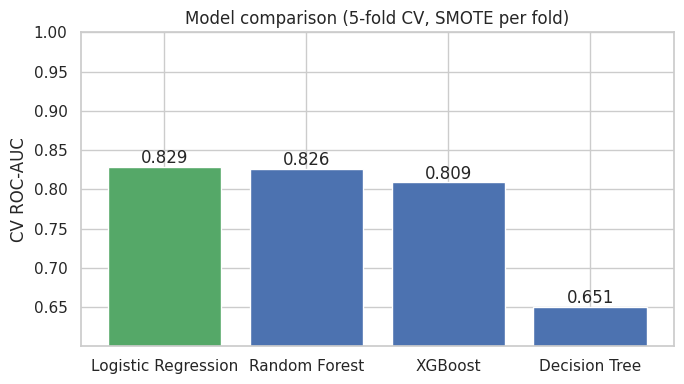

Best by CV ROC-AUC: Logistic Regression


In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
order_names = results_df.index.tolist()
best_name = results_df["roc_auc"].idxmax()
colors = ["#55A868" if n == best_name else "#4C72B0" for n in order_names]
ax.bar(order_names, results_df["roc_auc"], color=colors)
ax.set_ylim(results_df["roc_auc"].min() - 0.05, 1.0)
ax.set_ylabel("CV ROC-AUC")
ax.set_title("Model comparison (5-fold CV, SMOTE per fold)")
for i, v in enumerate(results_df["roc_auc"]):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()
print(f"Best by CV ROC-AUC: {best_name}")

## Do the engineered features actually help?

Checked directly, rather than assumed just because `attrition.py`
expected them to exist.

In [18]:
pipe_with = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])
pipe_with.fit(X_train, y_train)
auc_with = roc_auc_score(y_test, pipe_with.predict_proba(X_test)[:, 1])

preprocessor_wo = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_cols),
])
pipe_wo = ImbPipeline(steps=[
    ("preprocess", preprocessor_wo),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])
pipe_wo.fit(X_train[numeric_cols + categorical_cols], y_train)
auc_wo = roc_auc_score(y_test, pipe_wo.predict_proba(X_test[numeric_cols + categorical_cols])[:, 1])

print(f"Test AUC with engineered features:    {auc_with:.4f}")
print(f"Test AUC without engineered features:  {auc_wo:.4f}")

Test AUC with engineered features:    0.8134
Test AUC without engineered features:  0.7965


A real, if modest, improvement — the engineered features earn
their place rather than being cargo-culted in because the app assumed
them.

## Final model

**Logistic Regression is shipped** — and here, unlike some of the
other rebuilds in this series, it doesn't need a "close enough,
prefer interpretability" argument: it has the **highest CV ROC-AUC of
the four candidates outright** (0.829 vs Random Forest's 0.826,
XGBoost's 0.809, Decision Tree's 0.651), while also being the one
whose coefficients are directly readable — no trade-off to justify
here.

In [19]:
final_pipe = ImbPipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])
final_pipe.fit(X_train, y_train)

y_pred = final_pipe.predict(X_test)
y_proba = final_pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1:        {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")

Accuracy:  0.7857
Precision: 0.4000
Recall:    0.6809
F1:        0.5039
ROC-AUC:   0.8134


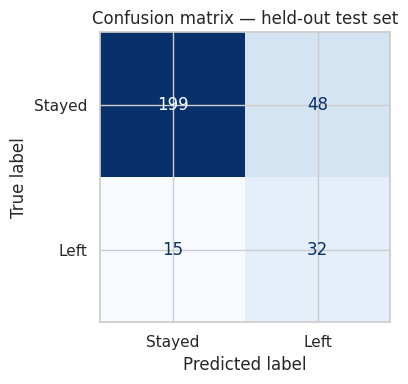

In [20]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Left"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix — held-out test set")
plt.tight_layout()
plt.show()

Recall (68%) matters more than precision here for a retention
tool: missing a real flight-risk employee costs more than a few extra
"check in with this person" flags. `class_weight="balanced"` plus
SMOTE inside training push recall up at a real, disclosed cost to
precision (40%) — about 6 in 10 people flagged as high-risk weren't
actually going to leave. That trade-off is stated plainly on the app's
Home page rather than left implicit.

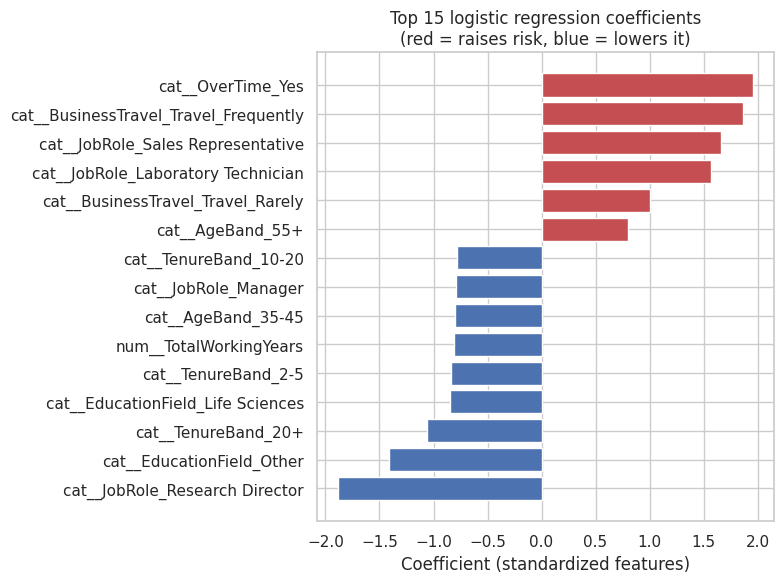

,feature,coef
39,cat__JobRole_Research Director,-1.884477
32,cat__EducationField_Other,-1.414468
48,cat__TenureBand_20+,-1.062360
29,cat__EducationField_Life Sciences,-0.845029
47,cat__TenureBand_2-5,-0.841652
16,num__TotalWorkingYears,-0.810868
51,cat__AgeBand_35-45,-0.801815
37,cat__JobRole_Manager,-0.796101
46,cat__TenureBand_10-20,-0.782387
53,cat__AgeBand_55+,0.800119


In [21]:
feature_names = final_pipe.named_steps["preprocess"].get_feature_names_out()
coefs = final_pipe.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
top15 = coef_df.sort_values("abs_coef", ascending=False).head(15).sort_values("coef")

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in top15["coef"]]
ax.barh(top15["feature"], top15["coef"], color=colors)
ax.set_title("Top 15 logistic regression coefficients\n(red = raises risk, blue = lowers it)")
ax.set_xlabel("Coefficient (standardized features)")
plt.tight_layout()
plt.show()

top15[["feature", "coef"]]

Overtime, frequent travel, and being a Sales Representative or
Laboratory Technician push risk up; long tenure, being a Research
Director or Manager, and rarely traveling pull it down — consistent
with the EDA above, not contradicting it.

In [22]:
import joblib
artifact = joblib.load("attrition_production_model.pkl")
print("Loaded artifact chosen model:", artifact["chosen_model"])
print("Test metrics from train_model.py:", artifact["test_metrics"])

Loaded artifact chosen model: Logistic Regression
Test metrics from train_model.py: {'accuracy': 0.7857142857142857, 'precision': 0.4, 'recall': 0.6808510638297872, 'f1': 0.5039370078740157, 'roc_auc': 0.8134206219312603}


## Summary

- Real attrition rate: **16.12%** (237 of 1,470 employees).
- Highest-risk group by far: **Sales Representatives (39.8%)** —
  not "Sales Reps and Technicians" as a tie, as the original app
  claimed.
- Overtime is the single starkest split in the data: **30.5% vs
  10.4%** attrition.
- The original notebook's entire modeling section never ran
  (undefined variables, cascading `NameError`s) — rebuilt from
  scratch here with a real 4-model comparison, SMOTE applied only
  inside CV folds/training, and a genuine, checked answer to whether
  the app's assumed engineered features actually help (they do, a
  little: test AUC 0.813 vs 0.797 without them).
- **Logistic Regression wins outright on CV ROC-AUC** (0.829) among
  the four candidates compared, and is shipped for that reason plus
  its interpretability — not as a close-call interpretability
  trade-off like some of the sibling rebuilds in this series.